In [2]:
import pickle
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

In [3]:
n_probes = 100
n_channels = 64
sim_flag = 'probes'

top_dir = os.path.dirname(os.path.dirname(os.getcwd()))
sim_dir = os.path.join(top_dir, 'models/NEURON/NMLCL000073-NEURON/output/LFP_basal')
sim_label = f'LFP_basal-0nA-50Ex1-1x40Hz-{n_probes}x{n_channels}lp-{sim_flag}'


eap_file_path = os.path.join(sim_dir, sim_label, f'{sim_label}-simulated_eaps.pkl')
probe_file_path = os.path.join(sim_dir, sim_label, f'{sim_label}-recording_probe_locs.pkl')

In [4]:
data_df = pd.read_pickle(eap_file_path)
probes = np.array(pd.read_pickle(probe_file_path))

In [5]:
num_probes, num_channels, _ = np.shape(probes)

probe_nums = []
channel_nums = []

for i, row in data_df.iterrows():
    probe_nums.append(int(i/num_channels))
    channel_nums.append(i%num_channels)

data_df['probe_num'] = probe_nums
data_df['channel_num'] = channel_nums

In [29]:
data_df.head()

,Model_ID,t,vm,ve,x_bar,y_bar,z_bar,num_spikes,did_spike,first_spkt,probe_num,channel_num
0,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[1.4683155998794908e-05, 1.4683033719120108e-0...",4.788917,-317.117009,15.918493,1147,True,408.071733,0,0
1,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[1.7234130407982727e-05, 1.7234009139822218e-0...",4.788917,-307.117009,15.918493,1147,True,408.071733,0,1
2,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[1.9768643569360802e-05, 1.9768523109521328e-0...",4.788917,-297.117009,15.918493,1147,True,408.071733,0,2
3,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[2.229151647911385e-05, 2.2291396496642475e-05...",4.788917,-287.117009,15.918493,1147,True,408.071733,0,3
4,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[2.4816832935173393e-05, 2.4816713131216955e-0...",4.788917,-277.117009,15.918493,1147,True,408.071733,0,4


In [7]:
def find_n_closest_probes(probes, n_closest, max_channel_i = 25):
    
    num_probes, _, _ = np.shape(probes)
    distances = []
    
    for i in range(num_probes):
        probe = probes[i,:,:]
        x,y,z = probe[max_channel_i]
        dist = np.sqrt(x**2+y**2+z**2)
        distances.append(dist)
        
    print('Closest probe found at %s microns...'%np.min(distances))
    return np.argsort(distances)[:n_closest]  # np.argmin(distances)

def find_n_farthest_probes(probes, n_farthest, max_channel_i = 25):
    
    num_probes, _, _ = np.shape(probes)
    distances = []
    
    for i in range(num_probes):
        probe = probes[i,:,:]
        x,y,z = probe[max_channel_i]
        dist = np.sqrt(x**2+y**2+z**2)
        distances.append(dist)
        
    print('Farthest probe found at %s microns...'%np.max(distances))
    return np.argsort(distances)[-n_farthest:]  # np.argmax(distances)

In [8]:
closest_probes = find_n_closest_probes(probes, n_probes//2, max_channel_i=n_channels//2)
closest_probes_df = data_df[data_df.probe_num.isin(closest_probes)]
closest_probes_df.head()

Closest probe found at 11.176532159151513 microns...


,Model_ID,t,vm,ve,x_bar,y_bar,z_bar,num_spikes,did_spike,first_spkt,probe_num,channel_num
0,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[1.4683155998794908e-05, 1.4683033719120108e-0...",4.788917,-317.117009,15.918493,1147,True,408.071733,0,0
1,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[1.7234130407982727e-05, 1.7234009139822218e-0...",4.788917,-307.117009,15.918493,1147,True,408.071733,0,1
2,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[1.9768643569360802e-05, 1.9768523109521328e-0...",4.788917,-297.117009,15.918493,1147,True,408.071733,0,2
3,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[2.229151647911385e-05, 2.2291396496642475e-05...",4.788917,-287.117009,15.918493,1147,True,408.071733,0,3
4,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[2.4816832935173393e-05, 2.4816713131216955e-0...",4.788917,-277.117009,15.918493,1147,True,408.071733,0,4


In [9]:
closest_probe = find_n_closest_probes(probes, 1, max_channel_i=n_channels//2)
closest_probe_df = data_df[data_df.probe_num.isin(closest_probe)]
closest_probe_df.head()

Closest probe found at 11.176532159151513 microns...


,Model_ID,t,vm,ve,x_bar,y_bar,z_bar,num_spikes,did_spike,first_spkt,probe_num,channel_num
4352,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[1.4557046339788114e-05, 1.455693599429246e-05...",-6.458654,-315.00852,7.634513,1147,True,408.071733,68,0
4353,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[1.6983757756701326e-05, 1.6983648745429887e-0...",-6.458654,-305.00852,7.634513,1147,True,408.071733,68,1
4354,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[1.936773590150133e-05, 1.9367627865172176e-05...",-6.458654,-295.00852,7.634513,1147,True,408.071733,68,2
4355,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[2.1732533931281357e-05, 2.1732426570531476e-0...",-6.458654,-285.00852,7.634513,1147,True,408.071733,68,3
4356,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[2.4094755009214806e-05, 2.4094648088360264e-0...",-6.458654,-275.00852,7.634513,1147,True,408.071733,68,4


In [10]:
np.unique(closest_probes_df.probe_num)

array([ 0,  1,  4,  8, 10, 12, 13, 15, 17, 19, 20, 25, 26, 29, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 42, 47, 49, 51, 54, 55, 59, 62, 63, 65,
       68, 69, 70, 71, 75, 76, 78, 80, 85, 87, 89, 92, 93, 94, 97, 99])

In [11]:
avg_waves_close = []

for channel_num in range(num_channels):

    channel_df = closest_probes_df[closest_probes_df.channel_num == channel_num]

    waves = []

    for _, row in channel_df.iterrows():

        ve = row.ve
        amp = np.max(ve) - np.min(ve)
        norm_ve = np.divide(ve, amp)
        wave = list(norm_ve)
        waves.append(wave)

    waves = np.array(waves)
    channel_avg = np.average(waves, 0)

    avg_waves_close.append(channel_avg)

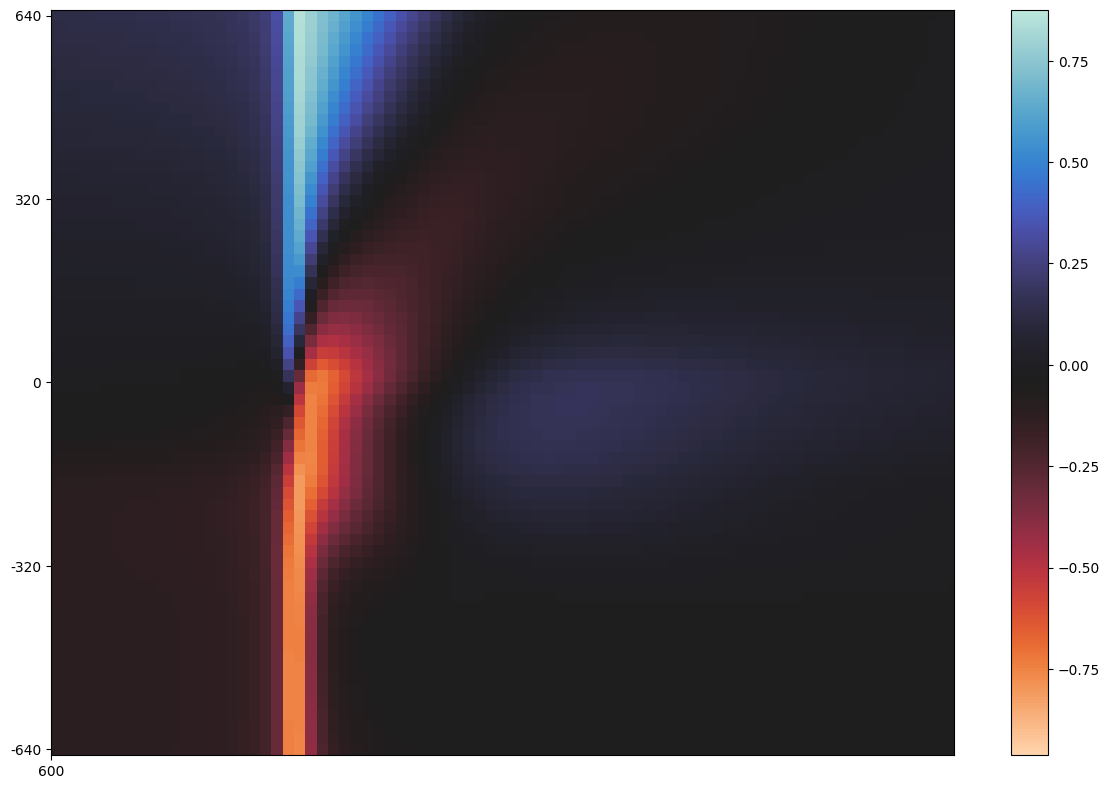

In [27]:
icefire_cmap = sns.color_palette("icefire_r", as_cmap=True)

fig, axs = plt.subplots(1,1, figsize=(12,8))
im = axs.imshow(avg_waves_close, interpolation='nearest', aspect='auto', cmap=icefire_cmap, zorder=1)
# axs.plot((-center_wave*64) + (n_channels-1)/2, color='white',zorder=12)
# axs.plot((-center_wave*60)+4, color='white',zorder=12)

axs.set_xticks([1000*i for i in range(0,7)])
axs.set_xticklabels([100*i for i in range(4,11)])
axs.set_xlim([2000, 2080])
# axs.set_yticks([0, 15, 31, 47, 63])
axs.set_yticks([(n_channels-1)*i for i in [0, 0.25, 0.5, 0.75, 1]])
axs.set_yticklabels([int(n_channels*i*10) for i in [1, 0.5, 0, -0.5, -1]])
# axs.set_yticklabels([320, 160, 0, -160, -320])
fig.colorbar(im)
fig.tight_layout()
fig.savefig(os.path.join(sim_dir, sim_label, 'closest_probes.png'), dpi=300)

## Farthest Probes

In [14]:
farthest_probes = find_n_farthest_probes(probes, n_probes//2, max_channel_i=n_channels//2)
farthest_probes_df = data_df[data_df.probe_num.isin(farthest_probes)]
farthest_probes_df.head()

Farthest probe found at 32.11033310655298 microns...


,Model_ID,t,vm,ve,x_bar,y_bar,z_bar,num_spikes,did_spike,first_spkt,probe_num,channel_num
128,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[1.3655621947126281e-05, 1.365550295982663e-05...",19.739821,-323.302918,14.702257,1147,True,408.071733,2,0
129,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[1.5973996276141474e-05, 1.597387642205759e-05...",19.739821,-313.302918,14.702257,1147,True,408.071733,2,1
130,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[1.837185264591956e-05, 1.8371732444274937e-05...",19.739821,-303.302918,14.702257,1147,True,408.071733,2,2
131,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[2.0825257878216612e-05, 2.0825137639752336e-0...",19.739821,-293.302918,14.702257,1147,True,408.071733,2,3
132,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[2.33211097541704e-05, 2.332098968637278e-05, ...",19.739821,-283.302918,14.702257,1147,True,408.071733,2,4


In [15]:
farthest_probe = find_n_farthest_probes(probes, 1, max_channel_i=n_channels//2)
farthest_probe_df = data_df[data_df.probe_num.isin(farthest_probe)]
farthest_probe_df.head()

Farthest probe found at 32.11033310655298 microns...


,Model_ID,t,vm,ve,x_bar,y_bar,z_bar,num_spikes,did_spike,first_spkt,probe_num,channel_num
896,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[1.3254017898681725e-05, 1.3253938743597239e-0...",-21.734218,-315.494051,-23.203312,1147,True,408.071733,14,0
897,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[1.5128915093851535e-05, 1.5128836801857231e-0...",-21.734218,-305.494051,-23.203312,1147,True,408.071733,14,1
898,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[1.7022558997414367e-05, 1.7022481722131495e-0...",-21.734218,-295.494051,-23.203312,1147,True,408.071733,14,2
899,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[1.8931652390301817e-05, 1.893157627939399e-05...",-21.734218,-285.494051,-23.203312,1147,True,408.071733,14,3
900,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[2.0855571282084985e-05, 2.0855496504396556e-0...",-21.734218,-275.494051,-23.203312,1147,True,408.071733,14,4


In [16]:
np.unique(farthest_probes_df.probe_num)

array([ 2,  3,  5,  6,  7,  9, 11, 14, 16, 18, 21, 22, 23, 24, 27, 28, 30,
       41, 43, 44, 45, 46, 48, 50, 52, 53, 56, 57, 58, 60, 61, 64, 66, 67,
       72, 73, 74, 77, 79, 81, 82, 83, 84, 86, 88, 90, 91, 95, 96, 98])

In [17]:
avg_waves_far = []

for channel_num in range(num_channels):

    channel_df = farthest_probes_df[farthest_probes_df.channel_num == channel_num]

    waves = []

    for _, row in channel_df.iterrows():

        ve = row.ve
        amp = np.max(ve) - np.min(ve)
        norm_ve = np.divide(ve, amp)
        wave = list(norm_ve)
        waves.append(wave)

    waves = np.array(waves)
    channel_avg = np.average(waves, 0)

    avg_waves_far.append(channel_avg)

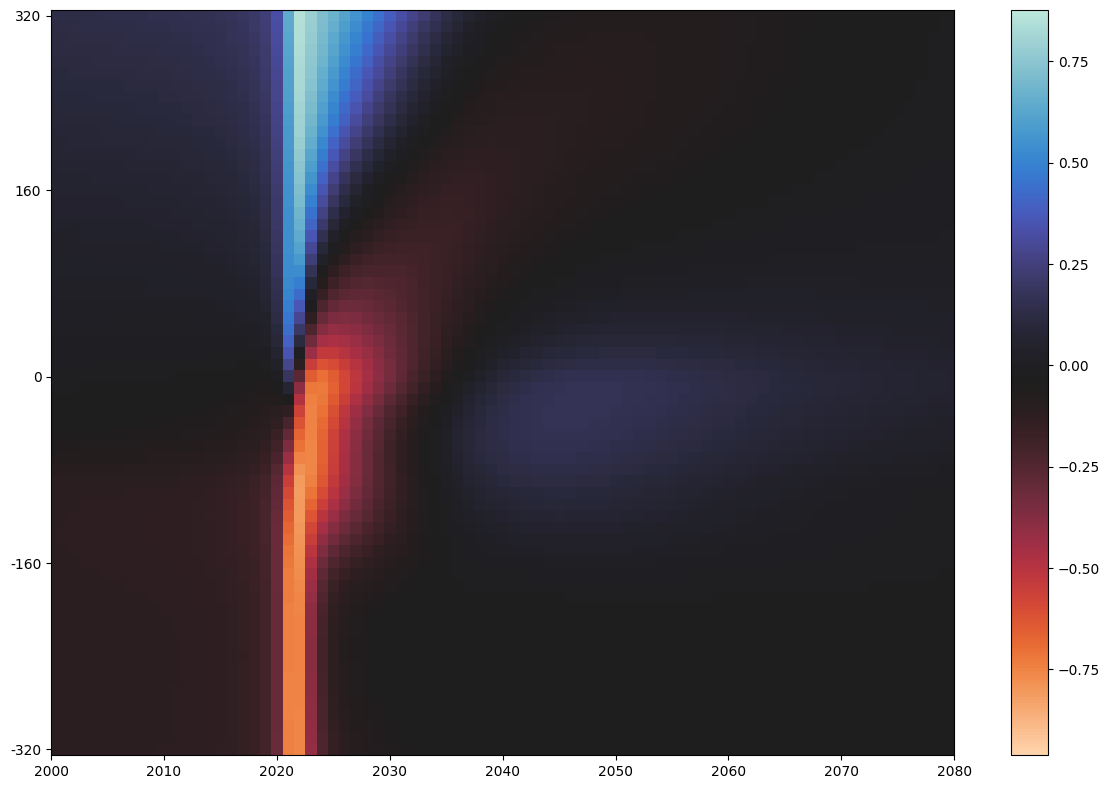

In [26]:
icefire_cmap = sns.color_palette("icefire_r", as_cmap=True)

fig, axs = plt.subplots(1,1, figsize=(12,8))
im = axs.imshow(avg_waves_far, interpolation='nearest', aspect='auto', cmap=icefire_cmap)
axs.set_xlim([2000, 2080])
axs.set_yticks([0, 15, 31, 47, 63])
axs.set_yticklabels([320, 160, 0, -160, -320])
fig.colorbar(im)
fig.tight_layout()
fig.savefig(os.path.join(sim_dir, sim_label, 'farthest_probes.png'), dpi=300)

### Compare farthest vs closest data

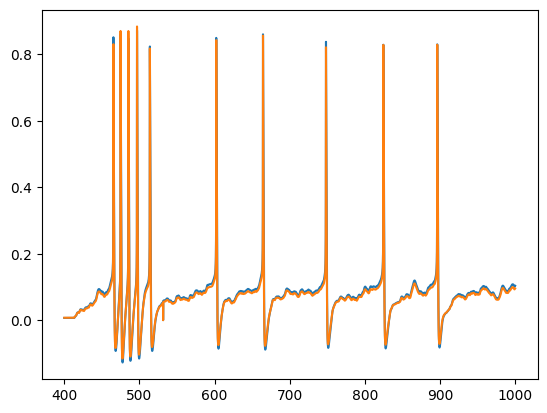

In [25]:
reduced_t = closest_probes_df.iloc[0].t[0:6000]

center_closest_ve = closest_probe_df.iloc[0].ve
norm_center_closest_ve = np.divide(center_closest_ve, np.max(center_closest_ve)-np.min(center_closest_ve))

x

plt.plot(reduced_t, norm_center_closest_ve)
plt.plot(reduced_t, norm_center_farthest_ve)

<!-- ### Plot heatmap
https://datascience.stackexchange.com/questions/93941/create-a-continuous-heatmap
 -->
